# On Analyzing Real World Time Series using the Wesad Dataset

[WESAD (Wearable Stress and Affect Detection)](https://archive.ics.uci.edu/dataset/465/wesad+wearable+stress+and+affect+detection)

In [1]:
import os
import sys

import pandas as pd

from tqdm import tqdm
# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# print(notebook_dir)

# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../../framework_for_time_series_data/tslearn/'))
# from collections import namedtuple
from data_loader import build_wesad_mts
from time_series import TimeSeriesFactory, TimeSeriesMixin, MultivariateTimeSeries

/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load Chest and Wrist Data

- Synchronised raw sensor data and labels

### Data Attributes

- Chest: RespiBAN device
    - Sampled at 700 Hz
    1. **ACC_x:**
    2. **ACC_y:**
    3. **ACC_z:**
    4. **ECG:**
    5. **EMG:**
    6. **EDA:**
    7. **Temp:**
    8. **Resp:**
    9. **Subject:** The participant in the study
    10. **Label:** ID of the respective study protocol condition
        - 0 = not defined / transient
        - 1 = baseline
        - 2 = stress
        - 3 = amusement
        - 4 = meditation
        - 5/6/7 = should be ignored in this dataset
- Wrist: Empatica E4 device


In [3]:
chest_mts, wrist_mts = build_wesad_mts()
chest_mts

MultivariateTimeSeries(ACC_x, ACC_y, ACC_z, ECG, EMG, EDA, Temp, Resp, subject, label)

## Down sample

- There exists 700 rows per 1 second. Can agg across 1 second or perform another analysis across all 700 rows for that 1 sec.

In [4]:
unit_of_time = 's'
start_time = 0
sampling_rate = 700  # Hz

chest_mts.update_with_sampling_rate(unit_of_time, start_time, sampling_rate)

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0 days 00:00:00,0.9554,-0.222,-0.558,0.021423,-0.00444,5.250549,30.120758,-1.148987,S2,0
0 days 00:00:00.001428571,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
0 days 00:00:00.002857142,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
0 days 00:00:00.004285713,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
0 days 00:00:00.005714284,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.13095,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
1 days 00:07:47.966796745,0.9006,-0.04,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
1 days 00:07:47.968225316,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.85974,0.233459,S17,0
1 days 00:07:47.969653887,0.9028,-0.0424,-0.1864,0.16713,-0.016068,7.262802,33.86429,0.318909,S17,0
1 days 00:07:47.971082458,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [5]:
categorical_cols_name = ['subject', 'label']
down_sampled_mts = chest_mts.avg_down_sample(unit_of_time, 1, categorical_cols_name)

DataFrame Columns: ['ACC_x', 'ACC_y', 'ACC_z', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp', 'subject', 'label']


In [6]:
down_sampled_df = down_sampled_mts.get_as_df()
down_sampled_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0 days 00:00:00,0.86331,-0.126381,-0.316446,0.014809,-0.002196,5.24494,30.123614,-0.691534,S2,0
0 days 00:00:01,0.863901,-0.128881,-0.315174,-0.186676,-0.002572,5.469644,30.104561,-0.28212,S2,0
0 days 00:00:02,0.864235,-0.126391,-0.315763,0.041944,-0.002708,6.267054,30.093263,1.392371,S2,0
0 days 00:00:03,0.864287,-0.128761,-0.316601,0.047376,-0.002593,6.408388,30.087257,-1.005144,S2,0
0 days 00:00:04,0.866042,-0.127169,-0.311073,0.071923,-0.002477,6.199835,30.088631,1.580869,S2,0
...,...,...,...,...,...,...,...,...,...,...
1 days 00:07:43,0.905652,-0.033825,-0.162897,0.01332,-0.004249,7.266557,33.876137,1.246602,S17,0
1 days 00:07:44,0.905782,-0.038767,-0.153111,-0.02085,-0.004076,7.267507,33.877395,-3.016388,S17,0
1 days 00:07:45,0.907431,-0.042242,-0.154084,0.002452,-0.004146,7.270962,33.869932,-6.130197,S17,0
1 days 00:07:46,0.901263,-0.0442,-0.184538,0.027803,-0.004362,7.27166,33.864445,-0.214791,S17,0


<Axes: >

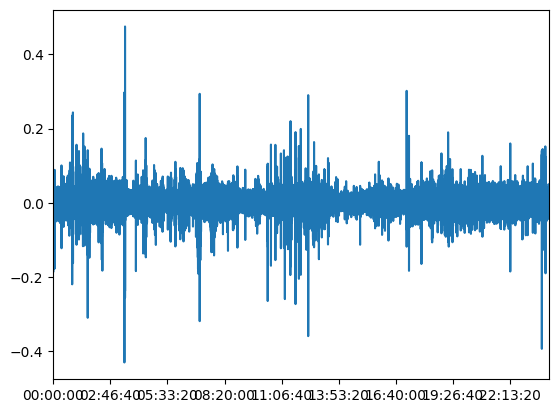

In [18]:
down_sampled_df['ECG'].plot()

## Normalize

- Scale the data to a specific range using methods like Min-Max scaling or Z-score normalization.

In [11]:
base_data_df = down_sampled_df.iloc[:, :8]
base_data_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp
0 days 00:00:00,0.86331,-0.126381,-0.316446,0.014809,-0.002196,5.24494,30.123614,-0.691534
0 days 00:00:01,0.863901,-0.128881,-0.315174,-0.186676,-0.002572,5.469644,30.104561,-0.28212
0 days 00:00:02,0.864235,-0.126391,-0.315763,0.041944,-0.002708,6.267054,30.093263,1.392371
0 days 00:00:03,0.864287,-0.128761,-0.316601,0.047376,-0.002593,6.408388,30.087257,-1.005144
0 days 00:00:04,0.866042,-0.127169,-0.311073,0.071923,-0.002477,6.199835,30.088631,1.580869
...,...,...,...,...,...,...,...,...
1 days 00:07:43,0.905652,-0.033825,-0.162897,0.01332,-0.004249,7.266557,33.876137,1.246602
1 days 00:07:44,0.905782,-0.038767,-0.153111,-0.02085,-0.004076,7.267507,33.877395,-3.016388
1 days 00:07:45,0.907431,-0.042242,-0.154084,0.002452,-0.004146,7.270962,33.869932,-6.130197
1 days 00:07:46,0.901263,-0.0442,-0.184538,0.027803,-0.004362,7.27166,33.864445,-0.214791


In [12]:
from sklearn.preprocessing import MinMaxScaler

# Assuming df is your DataFrame containing the WESAD data
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(base_data_df)
normalized_df = pd.DataFrame(normalized_data, columns=base_data_df.columns)
normalized_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp
0,0.882237,0.516238,0.349996,0.491495,0.972540,0.221375,0.856295,0.551747
1,0.882857,0.514239,0.350704,0.269114,0.970492,0.231591,0.855799,0.557235
2,0.883207,0.516230,0.350376,0.521444,0.969751,0.267845,0.855505,0.579682
3,0.883261,0.514335,0.349909,0.527440,0.970380,0.274271,0.855349,0.547543
4,0.885100,0.515608,0.352986,0.554532,0.971008,0.264789,0.855384,0.582209
...,...,...,...,...,...,...,...,...
86863,0.926600,0.590217,0.435450,0.489851,0.961353,0.313287,0.954007,0.577728
86864,0.926736,0.586267,0.440896,0.452137,0.962300,0.313330,0.954040,0.520581
86865,0.928464,0.583490,0.440355,0.477856,0.961915,0.313487,0.953846,0.478840
86866,0.922002,0.581925,0.423406,0.505837,0.960740,0.313519,0.953703,0.558137


## Denoise

- Remove noise from the data using techniques like moving average, wavelet transform, or Butterworth filter.

In [14]:
import numpy as np

# Assuming df is your DataFrame containing the WESAD data
window_size = 10  # Example window size
smoothed_data = normalized_df.rolling(window=window_size).mean().dropna()
smoothed_data

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp
9,0.882307,0.514332,0.349057,0.475574,0.970610,0.249496,0.855510,0.560678
10,0.881885,0.514060,0.348477,0.474748,0.970467,0.251375,0.855431,0.560026
11,0.882379,0.513663,0.348911,0.497079,0.970576,0.251921,0.855383,0.562434
12,0.883096,0.511408,0.351667,0.492386,0.970496,0.248629,0.855293,0.560239
13,0.885428,0.507551,0.356723,0.487803,0.970491,0.244562,0.855172,0.565603
...,...,...,...,...,...,...,...,...
86863,0.926400,0.588509,0.438482,0.477824,0.961435,0.314113,0.953353,0.577485
86864,0.926147,0.587402,0.436904,0.474826,0.961483,0.313935,0.953446,0.578496
86865,0.925954,0.586945,0.435644,0.474154,0.961520,0.313812,0.953531,0.574437
86866,0.925449,0.587075,0.434137,0.478027,0.961832,0.313701,0.953601,0.573972


<Axes: >

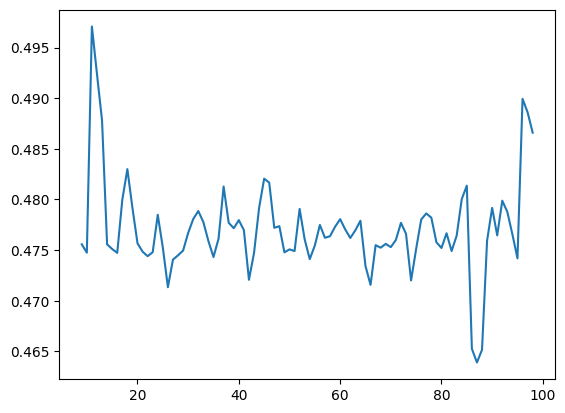

In [29]:
smoothed_data.iloc[:90, 3].plot()